In [1]:
import pandas as pd

# ---------------------------
# 1. Load marginal contributions
# ---------------------------
alloc = pd.read_csv("./logs/allocation_summary.csv")

# ---------------------------
# 2. Define site counts (rename to match CSV header)
# ---------------------------
site_counts = {
    1: 511,
    18: 382,
    4: 47,
    13: 35,
    21: 35,
    6: 34
}

counts_df = (
    pd.DataFrame(list(site_counts.items()), columns=["client", "Site_Count"])
)

# ---------------------------
# 3. Merge with allocation summary
# ---------------------------
merged = counts_df.merge(alloc, on="client", how="left")

# ---------------------------
# 4. Display
# ---------------------------
print(merged)


   client  Site_Count   shapley  least_core
0       1         511  0.177554    0.178211
1      18         382  0.133527    0.132618
2       4          47  0.135473    0.153893
3      13          35  0.138516    0.160683
4      21          35  0.069433    0.000000
5       6          34  0.135400    0.164500


In [2]:
import pandas as pd

# -------------------------------------------
# 1. Load coalition utilities CSV
# -------------------------------------------
coal = pd.read_csv("./logs/coalition_utilities.csv")

# -------------------------------------------
# 2. Define val metric columns and compute utility
# -------------------------------------------
val_cols = ["val_mean_dice", "val_tc", "val_wt", "val_et"]

# sanity check
for c in val_cols:
    if c not in coal.columns:
        raise ValueError(f"Expected column '{c}' not found in CSV. Got: {coal.columns}")
        
coal["utility"] = coal["val_mean_dice"]


# -------------------------------------------
# 3. Get top 5 and bottom 5 by utility
# -------------------------------------------
top5 = coal.nlargest(5, "utility").copy()
bottom5 = coal.nsmallest(5, "utility").copy()

top5["rank_group"] = "top_5"
bottom5["rank_group"] = "bottom_5"

# -------------------------------------------
# 4. Combine and display
# -------------------------------------------
summary_table = (
    pd.concat([top5, bottom5], axis=0)
    .sort_values("utility", ascending=False)
    .reset_index(drop=True)
)

summary_table


,coalition,size,val_mean_dice,val_tc,val_wt,val_et,utility,rank_group
0,"1,4,6,13,18,21",6,0.789905,0.733173,0.867730,0.798610,0.789905,top_5
1,"1,6,13,18",4,0.747481,0.691374,0.832806,0.747876,0.747481,top_5
2,"1,4,6,13,18",5,0.747339,0.691314,0.833803,0.746081,0.747339,top_5
3,"1,4,13,18",4,0.747218,0.692017,0.832299,0.746564,0.747218,top_5
4,"1,13,18",3,0.747117,0.691834,0.831083,0.748078,0.747117,top_5
5,"4,6,21",3,0.665740,0.591841,0.812136,0.611053,0.665740,bottom_5
6,"13,21",2,0.645032,0.584139,0.809338,0.549388,0.645032,bottom_5
7,"4,21",2,0.644050,0.581217,0.785336,0.578583,0.644050,bottom_5
8,"6,21",2,0.612145,0.518646,0.790677,0.541910,0.612145,bottom_5
9,21,1,0.443425,0.335756,0.667692,0.324938,0.443425,bottom_5


In [3]:
import pandas as pd

# -------------------------------------------
# 1. Load coalition utilities CSV
# -------------------------------------------
coal = pd.read_csv("./logs/coalition_utilities.csv")

# -------------------------------------------
# 2. Define val metric columns and compute utility
# -------------------------------------------
val_cols = ["val_mean_dice", "val_tc", "val_wt", "val_et"]

# sanity check
for c in val_cols:
    if c not in coal.columns:
        raise ValueError(f"Expected column '{c}' not found in CSV. Got: {coal.columns}")

# Use validation mean Dice as utility
coal["utility"] = coal["val_mean_dice"]

# -------------------------------------------
# 3. Compute global rank (including all coalitions)
# -------------------------------------------
coal = coal.sort_values("utility", ascending=False).reset_index(drop=True)
coal["global_rank"] = coal["utility"].rank(method="min", ascending=False).astype(int)

# -------------------------------------------
# 4. Filter out coalitions that include client 18
# -------------------------------------------
def contains_client(coalition_str, client_id=18):
    # coalition stored as "1,4,6,13,18,21" etc.
    members = [int(x) for x in str(coalition_str).split(",") if x.strip() != ""]
    return client_id in members

mask_no_18 = ~coal["coalition"].apply(contains_client)
coal_no_18 = coal[mask_no_18]

# -------------------------------------------
# 5. Take top 10 coalitions (without 18), but keep their global rank
# -------------------------------------------
top10_no_18 = (
    coal_no_18
    .sort_values("utility", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Optional: select/reorder columns for display
cols_to_show = [
    "global_rank",
    "coalition",
    "size",
    "utility",
    "val_mean_dice",
    "val_tc",
    "val_wt",
    "val_et",
]
top10_no_18[cols_to_show]


,global_rank,coalition,size,utility,val_mean_dice,val_tc,val_wt,val_et
0,17,"1,4,6,13,21",5,0.738164,0.738164,0.686723,0.821976,0.734674
1,18,"1,4,6,13",4,0.738038,0.738038,0.686960,0.820628,0.735660
2,19,"1,4,6,21",4,0.736032,0.736032,0.684669,0.816446,0.736793
3,20,"1,4,6",3,0.735199,0.735199,0.683963,0.814131,0.737697
4,21,"1,4,13,21",4,0.734800,0.734800,0.684926,0.816660,0.731751
5,22,"1,6,13,21",4,0.734314,0.734314,0.683022,0.816794,0.732382
6,23,"1,4,13",3,0.733881,0.733881,0.684428,0.814359,0.732082
7,24,"1,6,13",3,0.733054,0.733054,0.681935,0.814213,0.732598
8,25,"1,4,21",3,0.731822,0.731822,0.682041,0.809880,0.733507
9,26,"1,6,21",3,0.730959,0.730959,0.679459,0.809716,0.734089


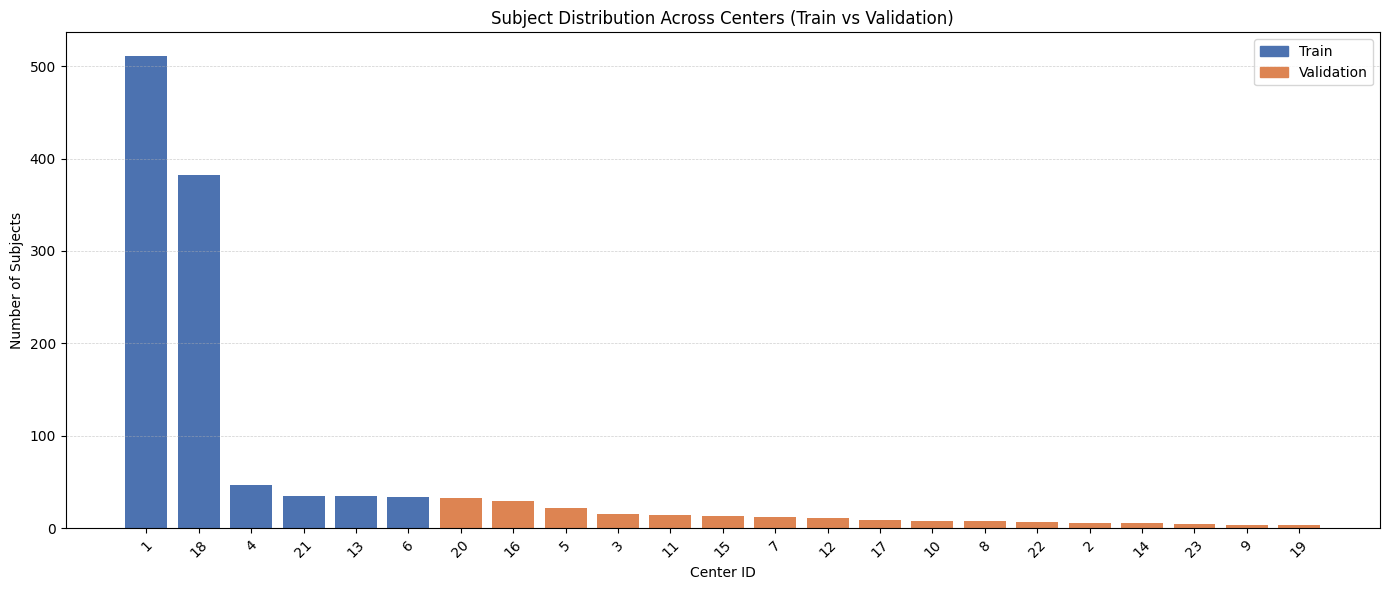

Saved figure to ./logs/center_distribution.pdf


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# -------------------------
# 1. Define subject counts
# -------------------------
train_centers = {
    1: 511,
    4: 47,
    6: 34,
    13: 35,
    18: 382,
    21: 35,
}

val_centers = {
    2: 6,
    3: 15,
    5: 22,
    7: 12,
    8: 8,
    9: 4,
    10: 8,
    11: 14,
    12: 11,
    14: 6,
    15: 13,
    16: 30,
    17: 9,
    19: 4,
    20: 33,
    22: 7,
    23: 5,
}

# Convert to DataFrame
df_train = pd.DataFrame({
    "Center": list(train_centers.keys()),
    "Subjects": list(train_centers.values()),
    "Split": "Train"
})

df_val = pd.DataFrame({
    "Center": list(val_centers.keys()),
    "Subjects": list(val_centers.values()),
    "Split": "Validation"
})

df = pd.concat([df_train, df_val], axis=0)

# Sort by subject count
df = df.sort_values("Subjects", ascending=False).reset_index(drop=True)

# -------------------------
# 2. Plot
# -------------------------
plt.figure(figsize=(14, 6))

colors = df["Split"].map({"Train": "#4C72B0", "Validation": "#DD8452"})

plt.bar(df["Center"].astype(str), df["Subjects"], color=colors)

plt.xlabel("Center ID")
plt.ylabel("Number of Subjects")
plt.title("Subject Distribution Across Centers (Train vs Validation)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# Legend
train_patch = plt.Rectangle((0,0),1,1, color="#4C72B0", label="Train")
val_patch   = plt.Rectangle((0,0),1,1, color="#DD8452", label="Validation")
plt.legend(handles=[train_patch, val_patch])

plt.tight_layout()

# -------------------------
# 3. Save as PDF
# -------------------------
os.makedirs("./logs", exist_ok=True)
pdf_path = "./logs/center_distribution.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")

plt.show()

print(f"Saved figure to {pdf_path}")


# Btw in general, here's the two partitions, if you need them:

/tmp/ipykernel_197/1171311125.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(df1["Center"].astype(str), rotation=45)
/tmp/ipykernel_197/1171311125.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df2["Center"].astype(str), rotation=45)


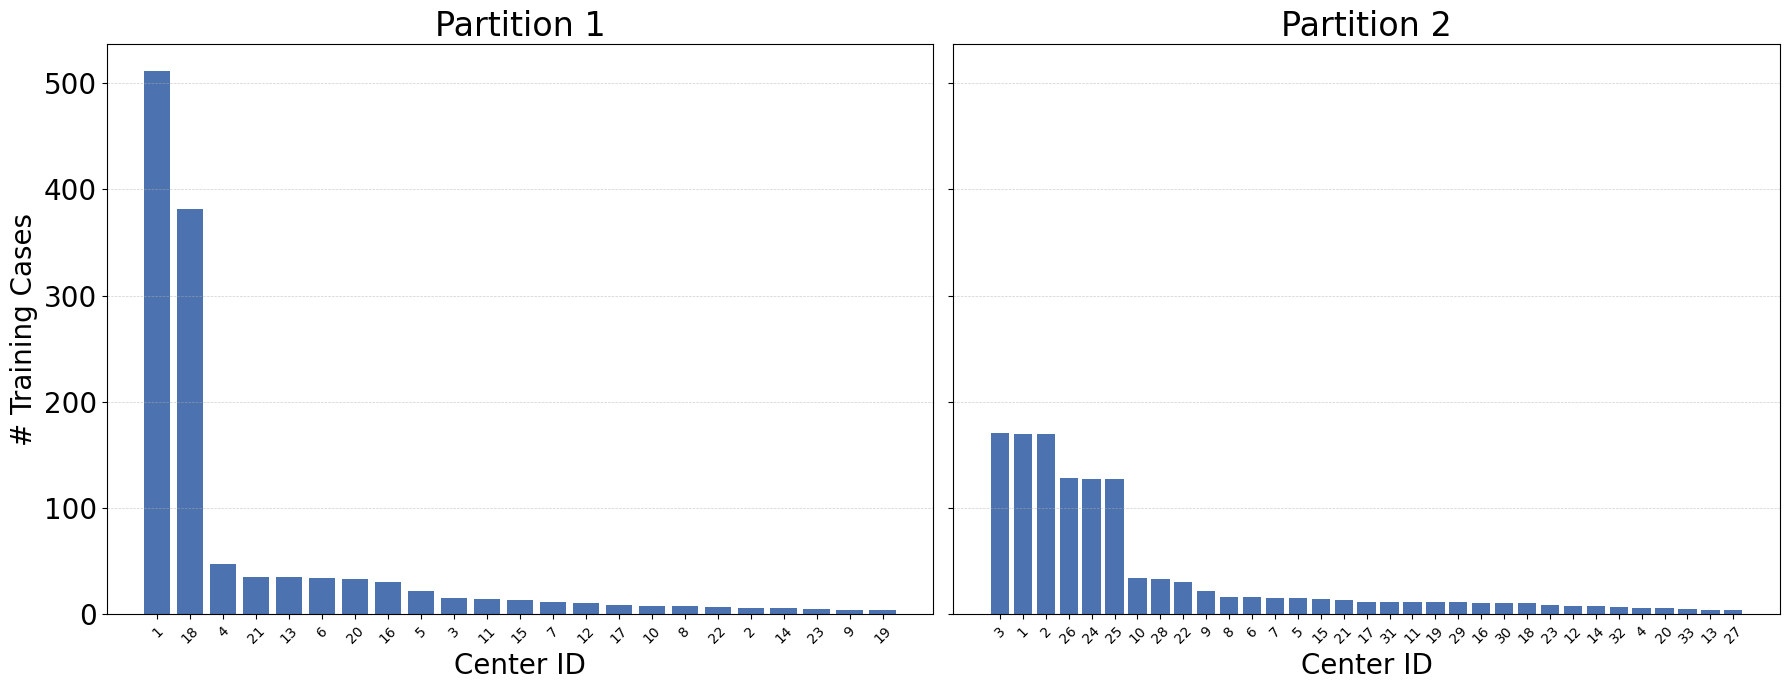

Saved figure to ./logs/partition_comparison.pdf


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ============================================================
# 1. Partition 1 (your original dictionary merged)
# ============================================================

train_centers = {
    1: 511,
    4: 47,
    6: 34,
    13: 35,
    18: 382,
    21: 35,
}

val_centers = {
    2: 6,
    3: 15,
    5: 22,
    7: 12,
    8: 8,
    9: 4,
    10: 8,
    11: 14,
    12: 11,
    14: 6,
    15: 13,
    16: 30,
    17: 9,
    19: 4,
    20: 33,
    22: 7,
    23: 5,
}

partition1 = {**train_centers, **val_centers}
df1 = pd.DataFrame({"Center": list(partition1.keys()),
                    "Subjects": list(partition1.values())})
df1 = df1.sort_values("Subjects", ascending=False)

# ============================================================
# 2. Partition 2 (your new distribution)
# ============================================================

partition2 = {
    3:171, 1:170, 2:170, 26:128, 24:127, 25:127, 10:34, 28:33, 22:30,
    9:22, 8:16, 6:16, 7:15, 5:15, 15:14, 21:13, 17:12, 31:12, 11:12,
    19:12, 29:12, 16:11, 30:11, 18:11, 23:9, 12:8, 14:8, 32:7, 4:6,
    20:6, 33:5, 13:4, 27:4
}

df2 = pd.DataFrame({"Center": list(partition2.keys()),
                    "Subjects": list(partition2.values())})
df2 = df2.sort_values("Subjects", ascending=False)

# ============================================================
# 3. Plot side-by-side
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

BIG = 2  # scale multiplier

# -------------------- Partition 1 --------------------
axes[0].bar(df1["Center"].astype(str), df1["Subjects"], color="#4C72B0")
axes[0].set_title("Partition 1", fontsize=BIG * 12)
axes[0].set_xlabel("Center ID", fontsize=BIG * 10)
axes[0].set_ylabel("# Training Cases", fontsize=BIG * 10)

# Remove X-axis numbers but keep ticks
# axes[0].set_xticklabels([""] * len(df1), rotation=45)
axes[0].set_xticklabels(df1["Center"].astype(str), rotation=45)

# Enlarge Y-axis tick labels
axes[0].tick_params(axis="y", labelsize=BIG * 10)

axes[0].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# -------------------- Partition 2 --------------------
axes[1].bar(df2["Center"].astype(str), df2["Subjects"], color="#4C72B0")
axes[1].set_title("Partition 2", fontsize=BIG * 12)
axes[1].set_xlabel("Center ID", fontsize=BIG * 10)

# Remove X-axis numbers
# axes[1].set_xticklabels([""] * len(df2), rotation=45)
axes[1].set_xticklabels(df2["Center"].astype(str), rotation=45)

axes[1].tick_params(axis="y", labelsize=BIG * 10)
axes[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()

# Save
os.makedirs("./logs", exist_ok=True)
pdf_path = "./logs/partition_comparison.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved figure to {pdf_path}")


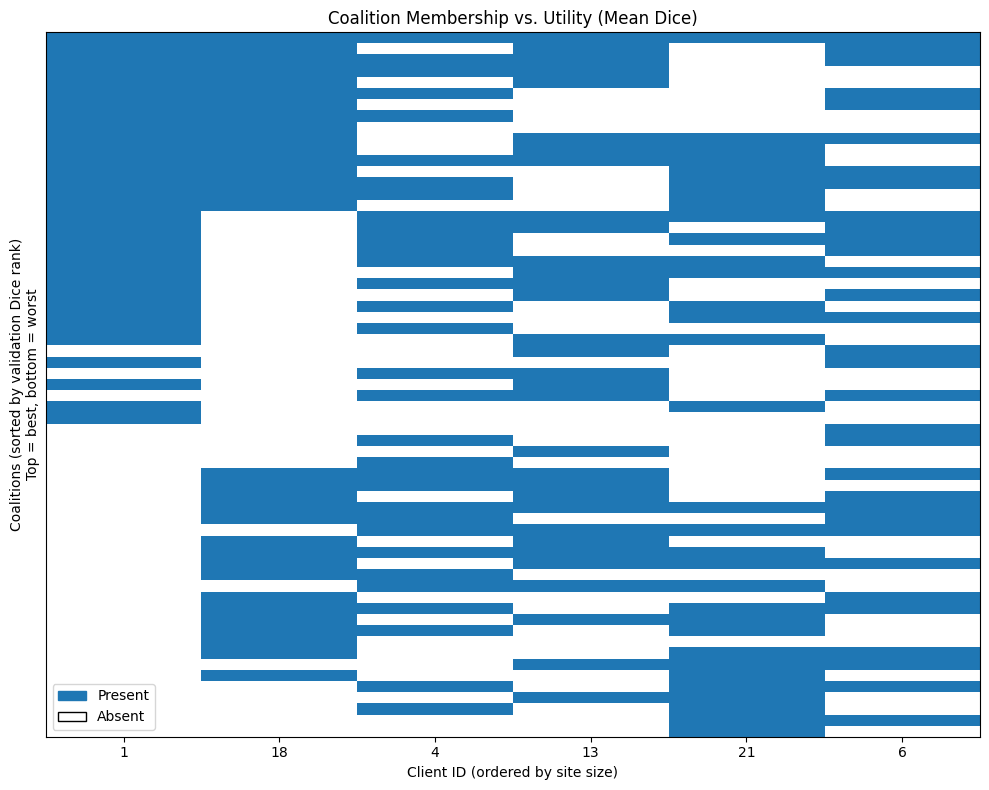

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Load coalition utilities
coal = pd.read_csv("./logs/coalition_utilities.csv")

# Utility = val_mean_dice
coal["utility"] = coal["val_mean_dice"]

# Sort coalitions by utility (best at top)
coal = coal.sort_values("utility", ascending=False).reset_index(drop=True)
coal["rank"] = coal.index + 1  # 1 = best coalition

# Client order (by site size)
ordered_clients = [1, 18, 4, 13, 21, 6]

# Build indicator matrix
indicator = np.zeros((len(coal), len(ordered_clients)))
for i, c in enumerate(coal["coalition"]):
    members = [int(x) for x in c.split(",")]
    for m in members:
        if m in ordered_clients:
            indicator[i, ordered_clients.index(m)] = 1

indicator_df = pd.DataFrame(indicator, columns=ordered_clients)

# Discrete colormap
cmap = ListedColormap(["white", "#1f77b4"])
norm = BoundaryNorm([0, 0.5, 1], cmap.N)

plt.figure(figsize=(10, 8))
plt.imshow(indicator_df.values, aspect="auto", cmap=cmap, norm=norm)

# Axes
plt.xticks(range(len(ordered_clients)), ordered_clients)
plt.xlabel("Client ID (ordered by site size)")
plt.yticks([])
plt.ylabel("Coalitions (sorted by validation Dice rank)\nTop = best, bottom = worst")
plt.title("Coalition Membership vs. Utility (Mean Dice)")

# -------------------------
# Legend (bottom left)
# -------------------------
present_patch = plt.Rectangle((0,0),1,1, color="#1f77b4", label="Present")
absent_patch  = plt.Rectangle((0,0),1,1, edgecolor="black", facecolor="white", label="Absent")

plt.legend(handles=[present_patch, absent_patch],
           loc="lower left",
           frameon=True)

plt.tight_layout()
plt.show()

pdf_path = "./logs/membership_matrix.pdf"
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()
print("Saved to:", pdf_path)



# Hierarchical clustering?

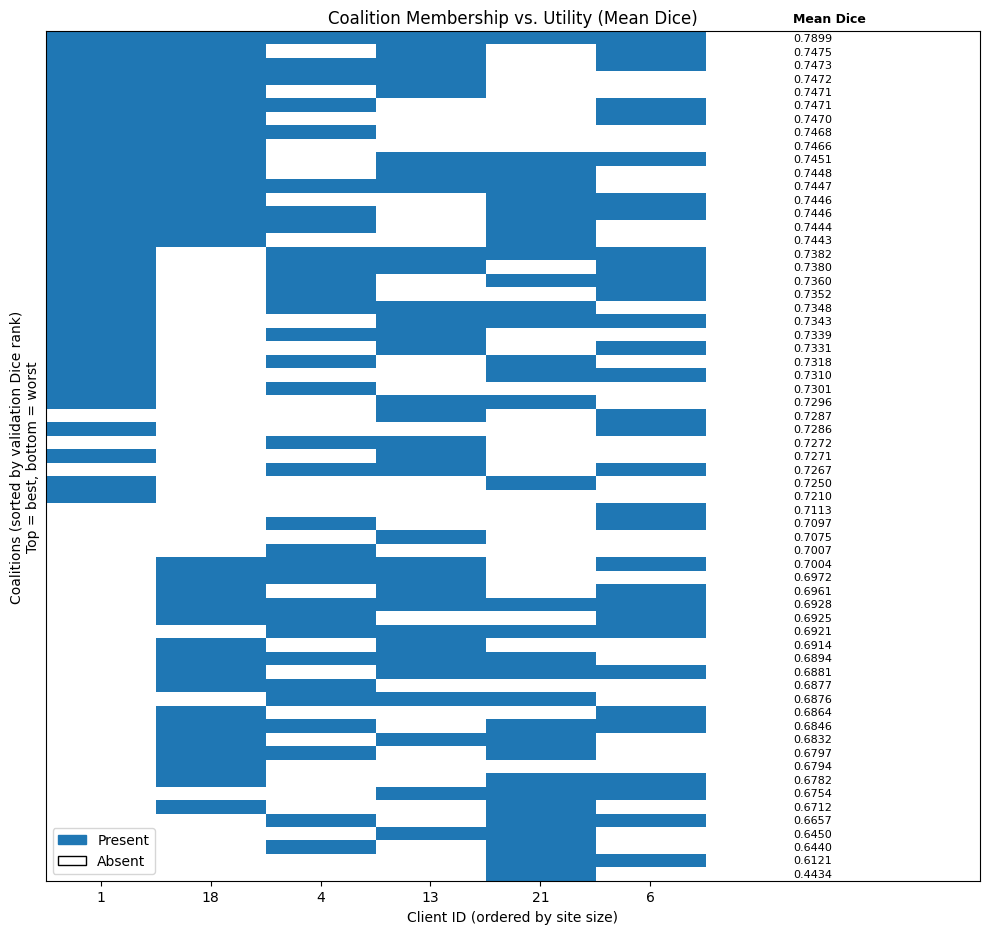

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Load coalition utilities
coal = pd.read_csv("./logs/coalition_utilities.csv")

# Utility = val_mean_dice
coal["utility"] = coal["val_mean_dice"]

# Sort coalitions by utility (best at top)
coal = coal.sort_values("utility", ascending=False).reset_index(drop=True)
coal["rank"] = coal.index + 1  # 1 = best coalition

# Client order (by site size)
ordered_clients = [1, 18, 4, 13, 21, 6]

# Build indicator matrix
indicator = np.zeros((len(coal), len(ordered_clients)))
for i, c in enumerate(coal["coalition"]):
    members = [int(x) for x in c.split(",")]
    for m in members:
        if m in ordered_clients:
            indicator[i, ordered_clients.index(m)] = 1

indicator_df = pd.DataFrame(indicator, columns=ordered_clients)

# -------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------
# Make height scale with number of coalitions so text isn't cramped
fig_height = max(6, len(coal) * 0.15)
fig, ax = plt.subplots(figsize=(10, fig_height))

# Discrete colormap
cmap = ListedColormap(["white", "#1f77b4"])
norm = BoundaryNorm([0, 0.5, 1], cmap.N)

im = ax.imshow(indicator_df.values, aspect="auto", cmap=cmap, norm=norm)

# Axes
ax.set_xticks(range(len(ordered_clients)))
ax.set_xticklabels(ordered_clients)
ax.set_xlabel("Client ID (ordered by site size)")
ax.set_yticks([])
ax.set_ylabel("Coalitions (sorted by validation Dice rank)\nTop = best, bottom = worst")
ax.set_title("Coalition Membership vs. Utility (Mean Dice)")

# Legend (bottom left)
present_patch = plt.Rectangle((0,0),1,1, color="#1f77b4", label="Present")
absent_patch  = plt.Rectangle((0,0),1,1, edgecolor="black", facecolor="white", label="Absent")
ax.legend(handles=[present_patch, absent_patch],
          loc="lower left",
          frameon=True)

# -------------------------------------------------------------------
# Add mean Dice next to each row
# -------------------------------------------------------------------
# Expand x-limits to make room for text on the right
x_min, x_max = ax.get_xlim()
n_clients = len(ordered_clients)
ax.set_xlim(x_min, n_clients + 2)  # +2 gives some padding

utilities = coal["utility"].values

for row_idx, u in enumerate(utilities):
    ax.text(
        n_clients + 0.3,   # just to the right of last column
        row_idx,
        f"{u:.4f}",        # format Dice to 4 decimals
        va="center",
        ha="left",
        fontsize=8,
    )

# Optional: label "Mean Dice" vertically on the right side
ax.text(
    n_clients + 0.3,
    -1.0,                # above the first row
    "Mean Dice",
    ha="left",
    va="bottom",
    fontsize=9,
    fontweight="bold"
)

plt.tight_layout()
plt.show()
pdf_path = "./logs/membership_with_dice.pdf"
fig.savefig(pdf_path, bbox_inches="tight")

# Manual hierarchical clustering

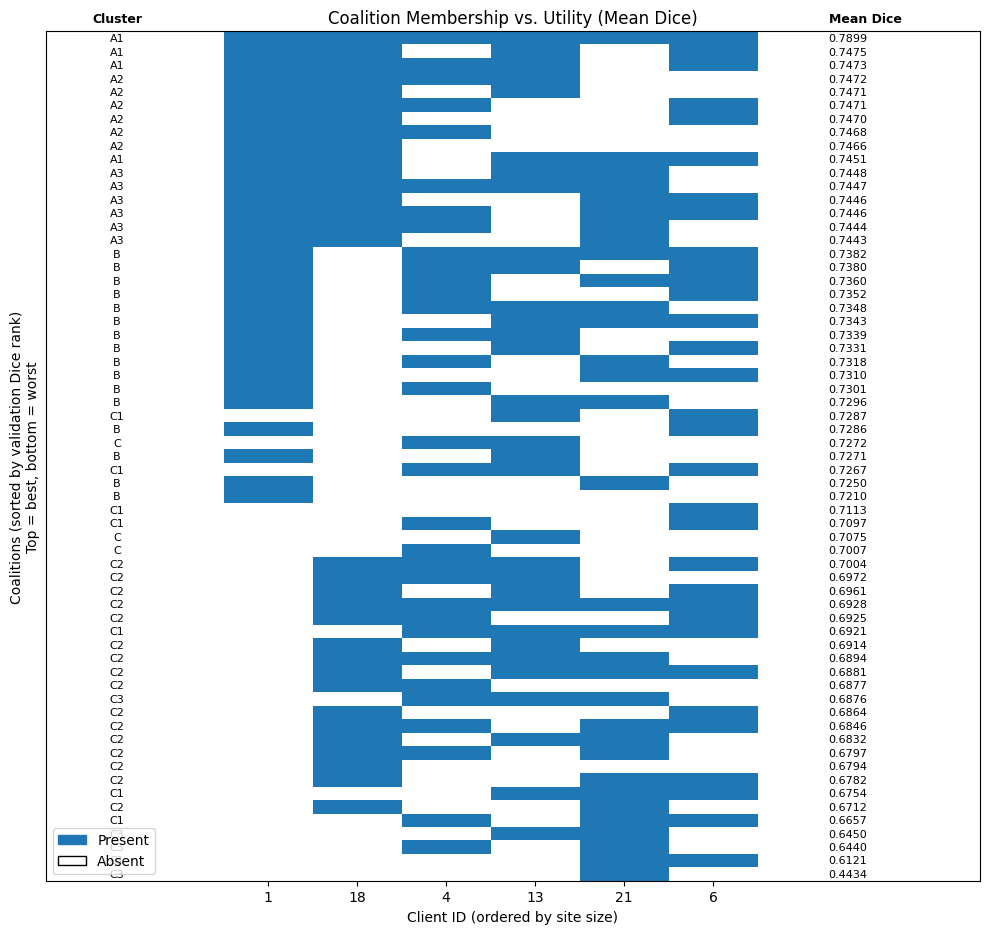

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ------------------------------------------------------------
# Load coalition utilities
# ------------------------------------------------------------
coal = pd.read_csv("./logs/coalition_utilities.csv")

# Utility = val_mean_dice
coal["utility"] = coal["val_mean_dice"]

# Sort coalitions by utility (best at top)
coal = coal.sort_values("utility", ascending=False).reset_index(drop=True)
coal["rank"] = coal.index + 1  # 1 = best coalition

# Client order (by site size)
ordered_clients = [1, 18, 4, 13, 21, 6]

# Build indicator matrix
indicator = np.zeros((len(coal), len(ordered_clients)))
for i, c in enumerate(coal["coalition"]):
    members = [int(x) for x in c.split(",")]
    for m in members:
        if m in ordered_clients:
            indicator[i, ordered_clients.index(m)] = 1

indicator_df = pd.DataFrame(indicator, columns=ordered_clients)

# ------------------------------------------------------------
# Manual cluster labels (A/A1/A2/A3, B, C/C1/C2/C3)
# ------------------------------------------------------------
col1  = indicator_df[1].values
col18 = indicator_df[18].values
col4  = indicator_df[4].values
col13 = indicator_df[13].values
col21 = indicator_df[21].values
col6  = indicator_df[6].values

n_rows = indicator_df.shape[0]
cluster_labels_str = np.array([""] * n_rows, dtype=object)

# Level 1 masks
mask_A = (col1 == 1) & (col18 == 1)
mask_B = (col1 == 1) & (col18 == 0)
mask_C = (col1 == 0)

# ---- A subclusters ----
mask_A_rem = mask_A.copy()

# A1: 1, 18, 13, 6 all included
mask_A1 = mask_A_rem & (col13 == 1) & (col6 == 1)
cluster_labels_str[mask_A1] = "A1"
mask_A_rem = mask_A_rem & (~mask_A1)

# A3: remaining A rows with 21 present (bottom among A)
mask_A3 = mask_A_rem & (col21 == 1)
cluster_labels_str[mask_A3] = "A3"
mask_A_rem = mask_A_rem & (~mask_A3)

# A2: all remaining A rows
cluster_labels_str[mask_A_rem] = "A2"

# ---- B (no subclusters for now) ----
cluster_labels_str[mask_B] = "B"

# ---- C subclusters ----
mask_C_rem = mask_C.copy()

# C1: 1 absent, 18 absent, 6 present
mask_C1 = mask_C_rem & (col18 == 0) & (col6 == 1)
cluster_labels_str[mask_C1] = "C1"
mask_C_rem = mask_C_rem & (~mask_C1)

# C2: remaining C rows with 18 present
mask_C2 = mask_C_rem & (col18 == 1)
cluster_labels_str[mask_C2] = "C2"
mask_C_rem = mask_C_rem & (~mask_C2)

# C3: remaining C rows with 21 present
mask_C3 = mask_C_rem & (col21 == 1)
cluster_labels_str[mask_C3] = "C3"
mask_C_rem = mask_C_rem & (~mask_C3)

# Any remaining C rows just "C"
cluster_labels_str[mask_C_rem] = "C"

# (Optional) sanity check
# unique, counts = np.unique(cluster_labels_str, return_counts=True)
# print(dict(zip(unique, counts)))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig_height = max(6, len(coal) * 0.15)
fig, ax = plt.subplots(figsize=(10, fig_height))

cmap = ListedColormap(["white", "#1f77b4"])
norm = BoundaryNorm([0, 0.5, 1], cmap.N)

im = ax.imshow(indicator_df.values, aspect="auto", cmap=cmap, norm=norm)

# Axes
ax.set_xticks(range(len(ordered_clients)))
ax.set_xticklabels(ordered_clients)
ax.set_xlabel("Client ID (ordered by site size)")
ax.set_yticks([])
ax.set_ylabel("Coalitions (sorted by validation Dice rank)\nTop = best, bottom = worst")
ax.set_title("Coalition Membership vs. Utility (Mean Dice)")

# Legend (bottom left)
present_patch = plt.Rectangle((0,0),1,1, color="#1f77b4", label="Present")
absent_patch  = plt.Rectangle((0,0),1,1, edgecolor="black", facecolor="white", label="Absent")
ax.legend(handles=[present_patch, absent_patch],
          loc="lower left",
          frameon=True)

# ------------------------------------------------------------
# Expand x-limits to make room LEFT (cluster) and RIGHT (Dice)
# ------------------------------------------------------------
n_clients = len(ordered_clients)
x_min, x_max = ax.get_xlim()
ax.set_xlim(-2.5, n_clients + 2)  # extra space left for labels

utilities = coal["utility"].values

# ------------------------------------------------------------
# Cluster labels on the LEFT
# ------------------------------------------------------------
for row_idx, label in enumerate(cluster_labels_str):
    ax.text(
        -1.7,               # left of first column
        row_idx,
        label,
        va="center",
        ha="center",
        fontsize=8,
    )

# Label header
ax.text(
    -1.7,
    -1.0,
    "Cluster",
    ha="center",
    va="bottom",
    fontsize=9,
    fontweight="bold"
)

# ------------------------------------------------------------
# Mean Dice on the RIGHT
# ------------------------------------------------------------
for row_idx, u in enumerate(utilities):
    ax.text(
        n_clients + 0.3,
        row_idx,
        f"{u:.4f}",
        va="center",
        ha="left",
        fontsize=8,
    )

ax.text(
    n_clients + 0.3,
    -1.0,
    "Mean Dice",
    ha="left",
    va="bottom",
    fontsize=9,
    fontweight="bold"
)

plt.tight_layout()


